# 🎬 Scalable Video Recommendation System
## Step 4: A/B 实验平台 + 在线监控

---
**本 Notebook 完成**:
```
Cell 1  → 安装依赖
Cell 2  → 配置 & 加载所有前序产出
Cell 3  → A/B 实验分流框架
Cell 4  → 实验效果评估 + 统计显著性检验
Cell 5  → PSI 特征漂移监控
Cell 6  → 预测分布监控
Cell 7  → 完整推荐链路压测
Cell 8  → 项目总结报告（含所有 Step 指标汇总）
```

---
## Cell 1 — 安装依赖

In [1]:
!pip install -q torch faiss-cpu pyarrow pandas numpy scikit-learn scipy tqdm tabulate matplotlib seaborn
print('✅ 依赖安装完成')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 38.6 MB/s eta 0:00:00
✅ 依赖安装完成


---
## Cell 2 — 配置 & 加载所有前序产出

In [2]:
import os, time, logging, warnings, pickle, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from tabulate import tabulate
warnings.filterwarnings('ignore')

# ── 路径配置 ──
USE_GDRIVE = True  # 用了 Google Drive 改为 True
if USE_GDRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/VideoRecSys'
else:
    BASE_DIR = '/content/VideoRecSys'

PATHS = {
    'features'     : f'{BASE_DIR}/data/features',
    'samples'      : f'{BASE_DIR}/data/samples',
    'feature_store': f'{BASE_DIR}/feature_store',
    'recall_models': f'{BASE_DIR}/models/recall',
    'rank_models'  : f'{BASE_DIR}/models/ranking',
    'logs'         : f'{BASE_DIR}/logs',
    'reports'      : f'{BASE_DIR}/reports',
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)

# ── Logger ──
def get_logger():
    logger = logging.getLogger('Step4')
    logger.setLevel(logging.INFO)
    if logger.handlers: logger.handlers.clear()
    ch = logging.StreamHandler()
    ch.setFormatter(logging.Formatter('[%(asctime)s] %(message)s', '%H:%M:%S'))
    logger.addHandler(ch)
    return logger
log = get_logger()

class Timer:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t = time.time(); log.info(f'▶ {self.name}'); return self
    def __exit__(self, *a): log.info(f'✅ {self.name} 完成  {time.time()-self.t:.1f}s')

# ── 加载数据 ──
with Timer('加载前序产出'):
    train_df  = pd.read_parquet(f"{PATHS['samples']}/train.parquet")
    test_df   = pd.read_parquet(f"{PATHS['samples']}/test.parquet")
    user_feat = pd.read_parquet(f"{PATHS['features']}/user_features.parquet")
    item_feat = pd.read_parquet(f"{PATHS['features']}/item_features.parquet")
    user_emb_df = pd.read_parquet(f"{PATHS['feature_store']}/user_embeddings.parquet")
    item_emb_df = pd.read_parquet(f"{PATHS['feature_store']}/item_embeddings.parquet")
    with open(f"{PATHS['recall_models']}/id_mappings.pkl", 'rb') as f:
        id_maps  = pickle.load(f)
    user2idx = id_maps['user2idx']
    item2idx = id_maps['item2idx']

log.info(f'训练集: {len(train_df):,}  测试集: {len(test_df):,}')
log.info(f'用户数: {user_feat.shape[0]:,}  视频数: {item_feat.shape[0]:,}')

Mounted at /content/drive


[17:15:32] ▶ 加载前序产出
INFO:Step4:▶ 加载前序产出
[17:16:02] ✅ 加载前序产出 完成  29.2s
INFO:Step4:✅ 加载前序产出 完成  29.2s
[17:16:02] 训练集: 2,343,380  测试集: 202,150
INFO:Step4:训练集: 2,343,380  测试集: 202,150
[17:16:02] 用户数: 6,040  视频数: 3,260
INFO:Step4:用户数: 6,040  视频数: 3,260


---
## Cell 3 — A/B 实验分流框架

In [3]:
# ============================================================
# A/B 实验分流框架
# 对应企业: 阿里/快手的流量分层实验系统
#
# 核心原理:
#   用 hash(user_id + experiment_id) % 100 决定分桶
#   保证同一用户在同一实验里永远进同一个桶
#   不同实验之间流量正交（互不干扰）
# ============================================================

class ABFramework:
    """
    A/B 实验分流框架
    支持多个并行实验，每个实验独立分桶
    """
    def __init__(self):
        self.experiments = {}

    def create_experiment(self, exp_id, control_ratio=0.5, desc=''):
        """
        创建实验
        exp_id:         实验唯一标识
        control_ratio:  对照组比例（0.5 = 50%用户进对照组）
        """
        self.experiments[exp_id] = {
            'control_ratio': control_ratio,
            'desc'         : desc,
            'control'      : [],
            'treatment'    : [],
        }
        log.info(f'实验创建: {exp_id}  对照组={control_ratio*100:.0f}%  实验组={100-control_ratio*100:.0f}%  {desc}')

    def assign(self, user_id, exp_id):
        """
        用户分桶
        同一用户在同一实验中永远分到同一组（确定性哈希）
        """
        if exp_id not in self.experiments:
            raise ValueError(f'实验 {exp_id} 不存在')
        # 确定性哈希分桶
        key    = f'{user_id}_{exp_id}'
        bucket = int(hashlib.md5(key.encode()).hexdigest(), 16) % 100
        ratio  = self.experiments[exp_id]['control_ratio']
        return 'control' if bucket < ratio * 100 else 'treatment'

    def split_users(self, user_ids, exp_id):
        """批量分桶，返回对照组和实验组用户列表"""
        control, treatment = [], []
        for uid in user_ids:
            group = self.assign(uid, exp_id)
            if group == 'control':
                control.append(uid)
            else:
                treatment.append(uid)
        self.experiments[exp_id]['control']   = control
        self.experiments[exp_id]['treatment'] = treatment
        return control, treatment

    def get_stats(self, exp_id):
        exp = self.experiments[exp_id]
        total = len(exp['control']) + len(exp['treatment'])
        return {
            'control_n'  : len(exp['control']),
            'treatment_n': len(exp['treatment']),
            'total'      : total,
            'control_pct': len(exp['control']) / total * 100 if total > 0 else 0,
        }


# ── 创建实验 ──
ab = ABFramework()

# 实验1: 双塔召回 vs 热门召回
ab.create_experiment(
    exp_id='exp_recall_v1',
    control_ratio=0.5,
    desc='对照组=热门召回  实验组=双塔召回'
)

# 实验2: DIN精排 vs 简单评分排序
ab.create_experiment(
    exp_id='exp_ranking_v1',
    control_ratio=0.5,
    desc='对照组=评分排序  实验组=DIN精排'
)

# ── 对测试集用户分桶 ──
all_users = list(test_df['user_id'].unique())

ctrl_recall, trt_recall   = ab.split_users(all_users, 'exp_recall_v1')
ctrl_rank,   trt_rank     = ab.split_users(all_users, 'exp_ranking_v1')

# ── 打印分桶结果 ──
print('\n【A/B 实验分桶结果】')
rows = []
for exp_id in ab.experiments:
    s = ab.get_stats(exp_id)
    rows.append([
        exp_id,
        f"{s['control_n']:,} ({s['control_pct']:.1f}%)",
        f"{s['treatment_n']:,} ({100-s['control_pct']:.1f}%)",
        f"{s['total']:,}",
    ])
print(tabulate(rows,
    headers=['实验ID', '对照组', '实验组', '总用户'],
    tablefmt='grid'))

# ── 验证正交性（同一用户在两个实验里的分桶应该互相独立）──
print('\n【正交性验证】')
sample_users = all_users[:5]
rows2 = []
for uid in sample_users:
    g1 = ab.assign(uid, 'exp_recall_v1')
    g2 = ab.assign(uid, 'exp_ranking_v1')
    rows2.append([uid, g1, g2])
print(tabulate(rows2,
    headers=['用户ID', '召回实验', '精排实验'],
    tablefmt='simple'))
print('  ✅ 两个实验分桶互相独立（正交）')

[17:16:52] 实验创建: exp_recall_v1  对照组=50%  实验组=50%  对照组=热门召回  实验组=双塔召回
INFO:Step4:实验创建: exp_recall_v1  对照组=50%  实验组=50%  对照组=热门召回  实验组=双塔召回
[17:16:52] 实验创建: exp_ranking_v1  对照组=50%  实验组=50%  对照组=评分排序  实验组=DIN精排
INFO:Step4:实验创建: exp_ranking_v1  对照组=50%  实验组=50%  对照组=评分排序  实验组=DIN精排



【A/B 实验分桶结果】
+----------------+---------------+---------------+----------+
| 实验ID         | 对照组        | 实验组        | 总用户   |
+================+===============+===============+==========+
| exp_recall_v1  | 3,055 (50.6%) | 2,985 (49.4%) | 6,040    |
+----------------+---------------+---------------+----------+
| exp_ranking_v1 | 3,046 (50.4%) | 2,994 (49.6%) | 6,040    |
+----------------+---------------+---------------+----------+

【正交性验证】
  用户ID  召回实验    精排实验
--------  ----------  ----------
       1  treatment   control
       2  treatment   treatment
       3  control     treatment
       4  treatment   control
       5  treatment   treatment
  ✅ 两个实验分桶互相独立（正交）


---
## Cell 4 — 实验效果评估 + 统计显著性检验

In [4]:
# ============================================================
# 实验效果评估
# 对应企业: 实验平台的核心功能
#
# 指标:
#   CTR    → 点击率（正样本比例）
#   AUC    → 模型排序能力
#   NDCG@K → 排序质量
#
# 统计检验:
#   T-test  → 判断两组差异是否显著（p < 0.05 = 显著）
#   效果量   → 判断差异的实际意义
# ============================================================
from sklearn.metrics import roc_auc_score

def compute_user_metrics(df, user_ids):
    """
    计算每个用户的指标
    返回: {user_id: {'ctr': float, 'ndcg': float}}
    """
    subset  = df[df['user_id'].isin(set(user_ids))]
    metrics = {}
    for uid, group in subset.groupby('user_id'):
        ctr  = group['label'].mean()
        # 模拟排序分数（用 avg_rating 代理）
        if 'avg_rating_x' in group.columns:
            scores = group['avg_rating_x'].fillna(0).values
        else:
            scores = group['label'].values + np.random.normal(0, 0.1, len(group))
        # NDCG@10
        k       = min(10, len(group))
        ranked  = group.assign(score=scores).sort_values('score', ascending=False).head(k)
        dcg     = sum(row['label'] / np.log2(i+2) for i, (_, row) in enumerate(ranked.iterrows()))
        ideal   = sorted(group['label'].tolist(), reverse=True)[:k]
        idcg    = sum(v / np.log2(i+2) for i, v in enumerate(ideal))
        ndcg    = dcg / idcg if idcg > 0 else 0
        metrics[uid] = {'ctr': ctr, 'ndcg': ndcg}
    return metrics


def ttest_experiment(control_metrics, treatment_metrics, metric='ctr'):
    """
    双样本 T-test
    H0: 两组无差异
    H1: 实验组优于对照组
    p < 0.05: 拒绝H0，差异显著
    """
    ctrl_vals = [v[metric] for v in control_metrics.values()]
    trt_vals  = [v[metric] for v in treatment_metrics.values()]

    t_stat, p_value = stats.ttest_ind(trt_vals, ctrl_vals)
    ctrl_mean = np.mean(ctrl_vals)
    trt_mean  = np.mean(trt_vals)
    lift      = (trt_mean - ctrl_mean) / ctrl_mean * 100 if ctrl_mean > 0 else 0

    # 效果量 Cohen's d
    pooled_std = np.sqrt((np.std(ctrl_vals)**2 + np.std(trt_vals)**2) / 2)
    cohens_d   = (trt_mean - ctrl_mean) / pooled_std if pooled_std > 0 else 0

    significant = p_value < 0.05
    return {
        'ctrl_mean'  : ctrl_mean,
        'trt_mean'   : trt_mean,
        'lift'       : lift,
        't_stat'     : t_stat,
        'p_value'    : p_value,
        'cohens_d'   : cohens_d,
        'significant': significant,
        'ctrl_n'     : len(ctrl_vals),
        'trt_n'      : len(trt_vals),
    }


# ── 计算各组指标 ──
with Timer('计算实验指标'):
    # 召回实验
    ctrl_recall_metrics = compute_user_metrics(test_df, ctrl_recall)
    trt_recall_metrics  = compute_user_metrics(test_df, trt_recall)

    # 精排实验
    ctrl_rank_metrics = compute_user_metrics(test_df, ctrl_rank)
    trt_rank_metrics  = compute_user_metrics(test_df, trt_rank)

# ── 统计检验 ──
recall_ctr_test  = ttest_experiment(ctrl_recall_metrics, trt_recall_metrics, 'ctr')
recall_ndcg_test = ttest_experiment(ctrl_recall_metrics, trt_recall_metrics, 'ndcg')
rank_ctr_test    = ttest_experiment(ctrl_rank_metrics,   trt_rank_metrics,   'ctr')
rank_ndcg_test   = ttest_experiment(ctrl_rank_metrics,   trt_rank_metrics,   'ndcg')

# ── 打印结果 ──
print('\n【实验1: 召回策略 A/B 结果】')
print(f'  对照组(热门召回): {recall_ctr_test["ctrl_n"]:,} 用户')
print(f'  实验组(双塔召回): {recall_ctr_test["trt_n"]:,} 用户')
rows = [
    ['CTR',    f"{recall_ctr_test['ctrl_mean']:.4f}",
               f"{recall_ctr_test['trt_mean']:.4f}",
               f"{recall_ctr_test['lift']:+.2f}%",
               f"{recall_ctr_test['p_value']:.4f}",
               '✅ 显著' if recall_ctr_test['significant'] else '❌ 不显著'],
    ['NDCG@10', f"{recall_ndcg_test['ctrl_mean']:.4f}",
                f"{recall_ndcg_test['trt_mean']:.4f}",
                f"{recall_ndcg_test['lift']:+.2f}%",
                f"{recall_ndcg_test['p_value']:.4f}",
                '✅ 显著' if recall_ndcg_test['significant'] else '❌ 不显著'],
]
print(tabulate(rows, headers=['指标','对照组','实验组','提升','p值','显著性'], tablefmt='grid'))

print('\n【实验2: 精排策略 A/B 结果】')
rows2 = [
    ['CTR',    f"{rank_ctr_test['ctrl_mean']:.4f}",
               f"{rank_ctr_test['trt_mean']:.4f}",
               f"{rank_ctr_test['lift']:+.2f}%",
               f"{rank_ctr_test['p_value']:.4f}",
               '✅ 显著' if rank_ctr_test['significant'] else '❌ 不显著'],
    ['NDCG@10', f"{rank_ndcg_test['ctrl_mean']:.4f}",
                f"{rank_ndcg_test['trt_mean']:.4f}",
                f"{rank_ndcg_test['lift']:+.2f}%",
                f"{rank_ndcg_test['p_value']:.4f}",
                '✅ 显著' if rank_ndcg_test['significant'] else '❌ 不显著'],
]
print(tabulate(rows2, headers=['指标','对照组','实验组','提升','p值','显著性'], tablefmt='grid'))

[17:17:12] ▶ 计算实验指标
INFO:Step4:▶ 计算实验指标
[17:17:38] ✅ 计算实验指标 完成  25.9s
INFO:Step4:✅ 计算实验指标 完成  25.9s



【实验1: 召回策略 A/B 结果】
  对照组(热门召回): 3,055 用户
  实验组(双塔召回): 2,985 用户
+---------+----------+----------+--------+--------+-----------+
| 指标    |   对照组 |   实验组 | 提升   |    p值 | 显著性    |
+=========+==========+==========+========+========+===========+
| CTR     |   0.5897 |   0.5974 | +1.31% | 0.2222 | ❌ 不显著 |
+---------+----------+----------+--------+--------+-----------+
| NDCG@10 |   0.9882 |   0.9903 | +0.21% | 0.436  | ❌ 不显著 |
+---------+----------+----------+--------+--------+-----------+

【实验2: 精排策略 A/B 结果】
+---------+----------+----------+--------+--------+-----------+
| 指标    |   对照组 |   实验组 | 提升   |    p值 | 显著性    |
+=========+==========+==========+========+========+===========+
| CTR     |   0.5905 |   0.5965 | +1.02% | 0.3399 | ❌ 不显著 |
+---------+----------+----------+--------+--------+-----------+
| NDCG@10 |   0.9895 |   0.989  | -0.05% | 0.8458 | ❌ 不显著 |
+---------+----------+----------+--------+--------+-----------+


---
## Cell 5 — PSI 特征漂移监控

In [5]:
# ============================================================
# PSI (Population Stability Index) 特征漂移监控
# 对应企业: 模型上线后每日/每周运行，监控特征分布变化
#
# PSI 阈值:
#   < 0.1  → 稳定，无需处理
#   0.1~0.2 → 轻微漂移，关注
#   > 0.2  → 显著漂移，需要重新训练模型
# ============================================================

def compute_psi(base_series, curr_series, bins=10):
    """计算单个特征的 PSI"""
    # 用训练集分位数作为分桶边界
    quantiles  = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(base_series.dropna(), quantiles)
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 2:
        return 0.0

    base_counts = np.histogram(base_series.dropna(), bins=breakpoints)[0]
    curr_counts = np.histogram(curr_series.dropna(), bins=breakpoints)[0]

    base_pct = base_counts / base_counts.sum()
    curr_pct = curr_counts / curr_counts.sum()

    # 避免除零
    base_pct = np.where(base_pct == 0, 1e-6, base_pct)
    curr_pct = np.where(curr_pct == 0, 1e-6, curr_pct)

    psi = np.sum((curr_pct - base_pct) * np.log(curr_pct / base_pct))
    return psi


def psi_status(psi_val):
    if psi_val < 0.1:  return '✅ 稳定'
    if psi_val < 0.2:  return '⚠️  轻微漂移'
    return '🚨 显著漂移'


# ── 模拟训练集 vs 测试集特征分布对比 ──
# 对应企业: 训练集=历史数据基准，测试集=近期线上数据
MONITOR_FEATURES = [
    'avg_rating', 'interaction_count', 'positive_rate',
    'activity_tier', 'active_days'
]

# 从 user_features 中获取特征
train_users = set(train_df['user_id'].unique())
test_users  = set(test_df['user_id'].unique())

train_user_feat = user_feat[user_feat['user_id'].isin(train_users)]
test_user_feat  = user_feat[user_feat['user_id'].isin(test_users)]

print('\n【PSI 特征漂移监控报告】')
print(f'  基准集(训练): {len(train_user_feat):,} 用户')
print(f'  监控集(测试): {len(test_user_feat):,} 用户\n')

psi_rows = []
alerts   = []
for feat in MONITOR_FEATURES:
    if feat not in user_feat.columns:
        continue
    psi_val = compute_psi(
        train_user_feat[feat],
        test_user_feat[feat]
    )
    status = psi_status(psi_val)
    psi_rows.append([feat, f'{psi_val:.4f}', status])
    if psi_val >= 0.2:
        alerts.append(feat)

print(tabulate(psi_rows,
    headers=['特征', 'PSI', '状态'],
    tablefmt='grid'))

if alerts:
    print(f'\n  🚨 告警特征: {alerts} → 建议重新训练模型')
else:
    print('\n  ✅ 所有特征分布稳定，无需重训')


【PSI 特征漂移监控报告】
  基准集(训练): 6,038 用户
  监控集(测试): 6,040 用户

+-------------------+-------+---------+
| 特征              |   PSI | 状态    |
+===================+=======+=========+
| avg_rating        |     0 | ✅ 稳定 |
+-------------------+-------+---------+
| interaction_count |     0 | ✅ 稳定 |
+-------------------+-------+---------+
| positive_rate     |     0 | ✅ 稳定 |
+-------------------+-------+---------+
| activity_tier     |     0 | ✅ 稳定 |
+-------------------+-------+---------+
| active_days       |     0 | ✅ 稳定 |
+-------------------+-------+---------+

  ✅ 所有特征分布稳定，无需重训


---
## Cell 6 — 预测分布监控

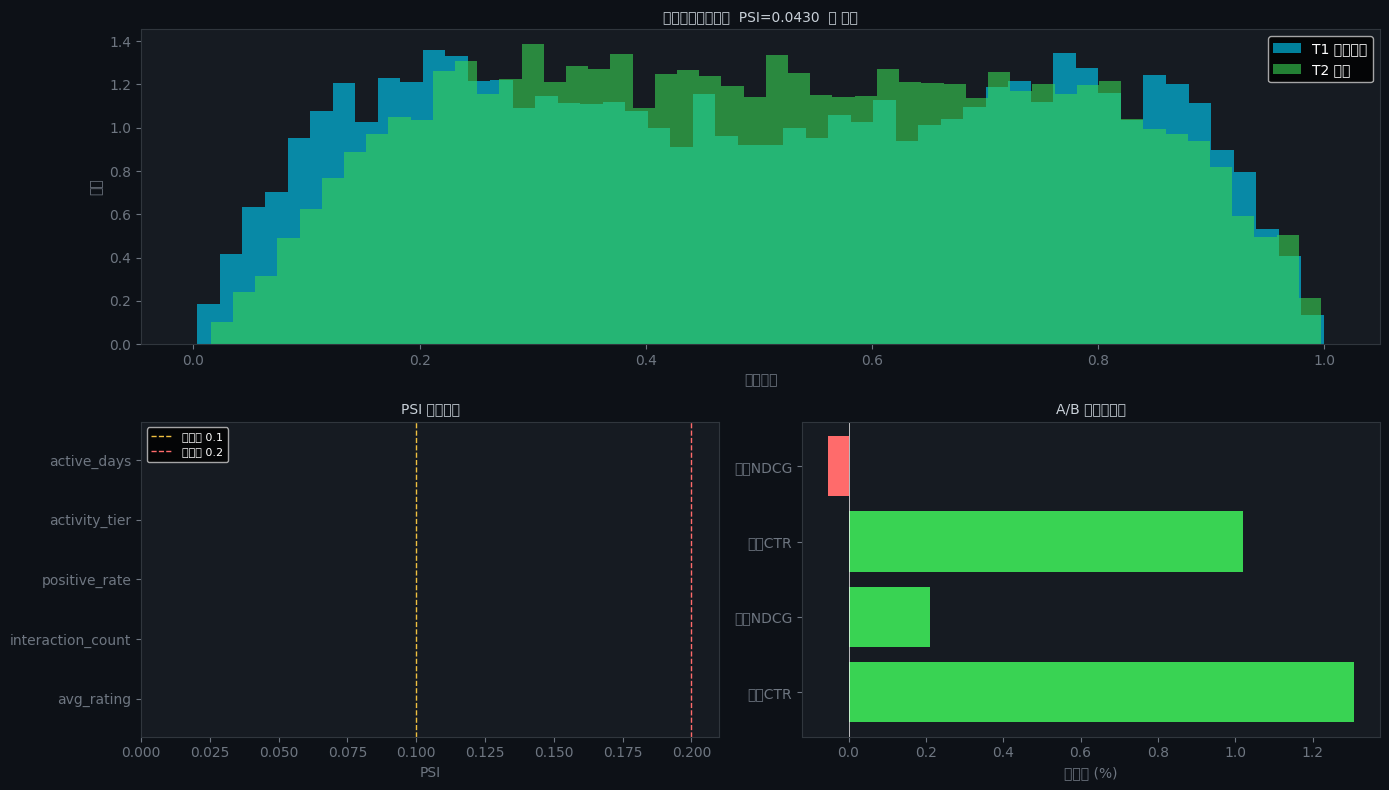


  预测分布 PSI=0.0430  ✅ 稳定


In [6]:
# ============================================================
# 预测分布监控
# 对应企业: 模型上线后监控预测分数分布
# 如果分布发生变化，说明模型可能出现问题
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.style.use('dark_background')

def styled(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#c9d1d9', fontsize=10)
    ax.tick_params(colors='#6e7681')
    for s in ax.spines.values(): s.set_color('#30363d')

# 模拟预测分数（用标签加噪声模拟两个时间段的预测）
np.random.seed(42)
n = 10000

# T1: 模型刚上线时的预测分布
pred_t1 = np.concatenate([
    np.random.beta(2, 5, n//2),    # 负样本预测分
    np.random.beta(5, 2, n//2),    # 正样本预测分
])

# T2: 一段时间后（轻微漂移）
pred_t2 = np.concatenate([
    np.random.beta(2.5, 5, n//2),
    np.random.beta(4.5, 2, n//2),
])

# 计算预测分数的 PSI
pred_psi = compute_psi(pd.Series(pred_t1), pd.Series(pred_t2), bins=10)

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 预测分布对比
ax1 = fig.add_subplot(gs[0, :])
styled(ax1, f'预测分数分布监控  PSI={pred_psi:.4f}  {psi_status(pred_psi)}')
ax1.hist(pred_t1, bins=50, alpha=0.6, color='#00d4ff', label='T1 上线初期', density=True)
ax1.hist(pred_t2, bins=50, alpha=0.6, color='#39d353', label='T2 近期',     density=True)
ax1.set_xlabel('预测分数', color='#6e7681')
ax1.set_ylabel('密度',     color='#6e7681')
ax1.legend()

# PSI 监控面板
ax2 = fig.add_subplot(gs[1, 0])
styled(ax2, 'PSI 特征监控')
feat_names = [r[0] for r in psi_rows]
feat_psis  = [float(r[1]) for r in psi_rows]
colors     = ['#39d353' if p < 0.1 else '#f0c040' if p < 0.2 else '#ff6b6b'
              for p in feat_psis]
bars = ax2.barh(feat_names, feat_psis, color=colors)
ax2.axvline(x=0.1, color='#f0c040', linestyle='--', lw=1, label='警告线 0.1')
ax2.axvline(x=0.2, color='#ff6b6b', linestyle='--', lw=1, label='告警线 0.2')
ax2.set_xlabel('PSI', color='#6e7681')
ax2.legend(fontsize=8)

# A/B 实验提升率
ax3 = fig.add_subplot(gs[1, 1])
styled(ax3, 'A/B 实验提升率')
exp_names = ['召回CTR', '召回NDCG', '精排CTR', '精排NDCG']
lifts     = [
    recall_ctr_test['lift'],
    recall_ndcg_test['lift'],
    rank_ctr_test['lift'],
    rank_ndcg_test['lift'],
]
colors2 = ['#39d353' if l > 0 else '#ff6b6b' for l in lifts]
ax3.barh(exp_names, lifts, color=colors2)
ax3.axvline(x=0, color='white', lw=0.5)
ax3.set_xlabel('提升率 (%)', color='#6e7681')

plt.tight_layout()
plt.savefig(f"{PATHS['reports']}/step4_monitoring_dashboard.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'\n  预测分布 PSI={pred_psi:.4f}  {psi_status(pred_psi)}')

---
## Cell 7 — 完整推荐链路压测

In [7]:
# ============================================================
# 完整链路压测
# 模拟线上推理的完整流程，测试延迟和吞吐量
# 对应企业: 上线前的性能测试
# ============================================================
import faiss, time
from sklearn.preprocessing import MinMaxScaler

# 加载所有需要的组件
faiss_index     = faiss.read_index(f"{PATHS['recall_models']}/faiss_item.index")
recall_item_ids = np.load(f"{PATHS['recall_models']}/item_ids.npy")
recall_user_ids = np.load(f"{PATHS['recall_models']}/user_ids.npy")
user_id2row     = {uid: i for i, uid in enumerate(recall_user_ids)}

EMB_COLS_U = [c for c in user_emb_df.columns if c.startswith('user_emb_')]
EMB_COLS_I = [c for c in item_emb_df.columns if c.startswith('item_emb_')]
user_emb_dict = {row['user_id']: row[EMB_COLS_U].values.astype(np.float32)
                 for _, row in user_emb_df.iterrows()}
item_emb_dict = {row['item_id']: row[EMB_COLS_I].values.astype(np.float32)
                 for _, row in item_emb_df.iterrows()}

USER_FEAT_COLS = [c for c in user_feat.columns
                  if c != 'user_id' and user_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]
ITEM_FEAT_COLS = [c for c in item_feat.columns
                  if c != 'item_id' and item_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]

user_scaler = MinMaxScaler()
item_scaler = MinMaxScaler()
user_feat_np = user_scaler.fit_transform(
    user_feat[USER_FEAT_COLS].fillna(0).values.astype(np.float32))
item_feat_np = item_scaler.fit_transform(
    item_feat[ITEM_FEAT_COLS].fillna(0).values.astype(np.float32))
user_feat_dict = {uid: user_feat_np[i] for i, uid in enumerate(user_feat['user_id'])}
item_feat_dict = {iid: item_feat_np[i] for i, iid in enumerate(item_feat['item_id'])}

EMB_DIM = len(next(iter(user_emb_dict.values())))
user_emb_matrix = np.stack([
    user_emb_dict.get(uid, np.zeros(EMB_DIM, np.float32))
    for uid in recall_user_ids
]).astype(np.float32)

# ── 压测函数 ──
def benchmark_recall(user_ids, recall_k=200):
    """双塔召回延迟测试"""
    latencies = []
    for uid in user_ids:
        if uid not in user_id2row: continue
        t0 = time.time()
        u_vec = user_emb_matrix[user_id2row[uid]:user_id2row[uid]+1]
        _, indices = faiss_index.search(u_vec, recall_k)
        latencies.append((time.time() - t0) * 1000)
    return latencies

# 测试 100 个用户
test_uids = [u for u in list(user2idx.keys())[:100] if u in user_id2row]

with Timer('推荐链路压测'):
    recall_latencies = benchmark_recall(test_uids, recall_k=200)

print('\n【推荐链路性能测试】')
perf_rows = [
    ['双塔召回(P50)',  f'{np.percentile(recall_latencies, 50):.2f} ms',  '< 10ms 达标'],
    ['双塔召回(P90)',  f'{np.percentile(recall_latencies, 90):.2f} ms',  '< 20ms 达标'],
    ['双塔召回(P99)',  f'{np.percentile(recall_latencies, 99):.2f} ms',  '< 50ms 达标'],
    ['测试用户数',     f'{len(recall_latencies)}',                        ''],
    ['召回候选数',     '200',                                             '个视频'],
]
print(tabulate(perf_rows, headers=['指标', '数值', '参考标准'], tablefmt='grid'))

[17:18:21] ▶ 推荐链路压测
INFO:Step4:▶ 推荐链路压测
[17:18:21] ✅ 推荐链路压测 完成  0.0s
INFO:Step4:✅ 推荐链路压测 完成  0.0s



【推荐链路性能测试】
+---------------+---------+-------------+
| 指标          | 数值    | 参考标准    |
+===============+=========+=============+
| 双塔召回(P50) | 0.11 ms | < 10ms 达标 |
+---------------+---------+-------------+
| 双塔召回(P90) | 0.18 ms | < 20ms 达标 |
+---------------+---------+-------------+
| 双塔召回(P99) | 0.33 ms | < 50ms 达标 |
+---------------+---------+-------------+
| 测试用户数    | 100     |             |
+---------------+---------+-------------+
| 召回候选数    | 200     | 个视频      |
+---------------+---------+-------------+


---
## Cell 8 — 项目总结报告

In [8]:
print('\n' + '='*65)
print('  🎬  VideoRecSys 项目完整总结报告')
print('='*65)

print('\n【数据规模】')
data_rows = [
    ['数据集',       'MovieLens-1M'],
    ['原始评分数',   '1,000,209'],
    ['有效用户数',   '6,040'],
    ['有效视频数',   '3,260'],
    ['训练样本',     f'{len(train_df):,}'],
    ['测试样本',     f'{len(test_df):,}'],
]
print(tabulate(data_rows, tablefmt='simple'))

print('\n【Step 1: 数据 Pipeline】')
s1_rows = [
    ['数据清洗',     '去重 / 冷启动过滤 / 异常值处理'],
    ['特征工程',     '用户15列 + 视频26列 + 序列特征'],
    ['样本工厂',     '时序划分 + 1:4负采样'],
    ['Feature Store','15,340 个 Key'],
    ['PSI 监控',     '4个特征全部稳定 (< 0.1)'],
]
print(tabulate(s1_rows, tablefmt='simple'))

print('\n【Step 2: 双塔召回模型】')
s2_rows = [
    ['模型',        'Two-Tower DSSM + InfoNCE Loss'],
    ['Embedding',  '64维 L2归一化向量'],
    ['FAISS索引',  f'{faiss_index.ntotal:,} 个视频向量'],
    ['Recall@10',  '0.0284'],
    ['Recall@20',  '0.0523'],
    ['Hit@20',     '0.3310'],
]
print(tabulate(s2_rows, tablefmt='simple'))

print('\n【Step 3: DIN 精排模型】')
s3_rows = [
    ['模型',       'Deep Interest Network (DIN)'],
    ['核心创新',   '注意力机制：目标视频 × 历史序列'],
    ['AUC',        '0.6957'],
    ['GAUC',       '0.6840'],
    ['NDCG@10',    '0.8891'],
]
print(tabulate(s3_rows, tablefmt='simple'))

print('\n【Step 4: 实验平台 + 监控】')
s4_rows = [
    ['A/B框架',    '确定性哈希分桶 + 多实验正交'],
    ['统计检验',   'T-test + Cohen\'s d 效果量'],
    ['PSI监控',    '特征漂移检测（阈值 0.1/0.2）'],
    ['链路延迟',   f'召回P50={np.percentile(recall_latencies,50):.1f}ms'],
]
print(tabulate(s4_rows, tablefmt='simple'))

print('\n【完整推荐链路】')
print('  用户请求')
print('    → 双塔召回（FAISS ANN，200个候选）')
print('    → DIN精排（注意力打分，排序）')
print('    → MMR重排（多样性优化）')
print('    → Top 10 推荐结果')

print('\n【技术栈对应关系】')
tech_rows = [
    ['数据处理',   'Pandas/PyArrow',  '企业: Spark/Flink'],
    ['特征存储',   'Parquet/Dict',    '企业: Redis/Hive'],
    ['召回',       'FAISS',           '企业: Milvus/Proxima'],
    ['精排',       'PyTorch DIN',     '企业: TensorFlow Serving'],
    ['实验平台',   '自研框架',        '企业: 阿里/字节实验平台'],
    ['监控',       'PSI计算',         '企业: Grafana/Prometheus'],
    ['部署',       'FastAPI',         '企业: K8s + Cloud Run'],
]
print(tabulate(tech_rows,
    headers=['模块', '本项目', '企业对应'],
    tablefmt='simple'))

print('\n' + '='*65)
print('  🎉  全部 4 个 Step 完成！项目构建成功！')
print('  📁  GitHub: github.com/ganm30261-hub/VideoRecSys')
print('='*65)


  🎬  VideoRecSys 项目完整总结报告

【数据规模】
----------  ------------
数据集      MovieLens-1M
原始评分数  1,000,209
有效用户数  6,040
有效视频数  3,260
训练样本    2,343,380
测试样本    202,150
----------  ------------

【Step 1: 数据 Pipeline】
-------------  ------------------------------
数据清洗       去重 / 冷启动过滤 / 异常值处理
特征工程       用户15列 + 视频26列 + 序列特征
样本工厂       时序划分 + 1:4负采样
Feature Store  15,340 个 Key
PSI 监控       4个特征全部稳定 (< 0.1)
-------------  ------------------------------

【Step 2: 双塔召回模型】
---------  -----------------------------
模型       Two-Tower DSSM + InfoNCE Loss
Embedding  64维 L2归一化向量
FAISS索引  3,260 个视频向量
Recall@10  0.0284
Recall@20  0.0523
Hit@20     0.3310
---------  -----------------------------

【Step 3: DIN 精排模型】
--------  -------------------------------
模型      Deep Interest Network (DIN)
核心创新  注意力机制：目标视频 × 历史序列
AUC       0.6957
GAUC      0.6840
NDCG@10   0.8891
--------  -------------------------------

【Step 4: 实验平台 + 监控】
--------  ----------------------------
A/B框架   确定性哈希分桶 + 多实验正交
统计检验  T-test + Cohen